In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# add utils folder to path
from data import load_sc_data

device = torch.device('cpu')


ModuleNotFoundError: No module named 'data'

In [3]:
img_downsample = 2
use_sensorium_normalization = False
use_zscore_normalization = True

# helper functions

In [4]:
import approxineuro.encoder_multiconv as encoder

def build_model(n_layers, n_conv, n_conv_mid,highres=True, multikernel=False, multikernel_sizes=[9,25,49], 
                depth_separable=True, pool=True, clamp=True, use_sensorium_normalization=True):
    if use_sensorium_normalization: loss_function = 'poisson'
    else: loss_function = 'mse'

    dense = False
    if pool: stride = 1
    else: stride = 2 if highres else 1
    in_channels = [1, n_conv]
    # in_channels = [1, 16, 32, 64, 128, 320]
    # in_channels = in_channels[:(n_layers+1)]
    kernel_size = [25, 9] if highres else [9, 9]

    for n in range(1, n_layers):
        in_channels.append(n_conv_mid)
        kernel_size.append(5)

    neurons_params = None       
    core = encoder.Core(in_channels, kernel_size, stride, 
                        dense=dense, multikernel=multikernel, kernel_size_conv1=multikernel_sizes, \
                        depth_separable=depth_separable, pool=pool)#[::2])

    in_shape = (in_channels[-1], input_Ly//(2 if highres else 1), input_Lx//(2 if highres else 1))
    # in_shape = (in_channels[-1], input_Ly, input_Lx)
    print('input shape of readout: ', in_shape)

    readout = encoder.Readout(in_shape, len(ineur), rank=1,
                                    yx_separable=True, sigma=0., bias_init=None, poisson=use_sensorium_normalization) #-spks_mean[ineur])

    model = encoder.Encoder(core, readout, loss_fun=loss_function).to(device)
    return model, in_channels

def create_model_name(weight_path, in_channels, fev_threshold, highres=True, multikernel=False, multikernel_sizes=[9,25,49], 
                      depth_separable=True, pool=True, clamp=True, use_sensorium_normalization=True, gabor=False, 
                      rank=1, orth_reg=0, highvar=False, use_30k=False, l1_readout=0.0):
    n_layers = len(in_channels) - 1
    model_save_name = os.path.join(weight_path, f'sc_{n_layers}layer_fev{fev_threshold}')
    for nc in in_channels[1:]:
        model_save_name += f'_{nc}'
    if clamp:
        model_save_name += '_clamp'
    if multikernel:
        model_save_name += '_multikernel'
        for k in multikernel_sizes:
            model_save_name += f'_{k}'
    if use_sensorium_normalization:
        model_save_name += '_sensorium'
    if gabor:
        model_save_name += '_gabor'
    if rank > 1:
        model_save_name += f'_Wcrank{rank}'
    if depth_separable:
        model_save_name += '_depthsep'
    if pool:
        model_save_name += '_pool'
    if orth_reg > 0:
        model_save_name += f'_orth{orth_reg}'
    if highvar:
        model_save_name += '_highvar'
    if use_30k:
        model_save_name += '_30k'
    if l1_readout > 0:
        model_save_name += f'_l1readout{l1_readout}'
    model_path = model_save_name + '.pt'
    return model_path

# load data

In [339]:
fev_threshold = -1
ineur = np.where(fev_all > fev_threshold)[0]
print(f'selecting {len(ineur)} neurons with fev > {fev_threshold}') 

spks_train = torch.from_numpy(spks_train[ineur].T)
spks_val = torch.from_numpy(spks_val[ineur].T)
spks_test_rep = torch.from_numpy(spks_test_rep[:, ineur])    
spks_test = spks_test_rep[0].T

print(spks_train.shape, spks_val.shape, spks_test.shape)

img_train = torch.from_numpy(img_train).to(device).unsqueeze(1)
img_val = torch.from_numpy(img_val).to(device).unsqueeze(1)
img_test = torch.from_numpy(img_test).to(device).unsqueeze(1)

print(img_train.shape, img_val.shape, img_test.shape)

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test.shape, spks_test.min(), spks_test.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

input_Ly, input_Lx = img_train.shape[-2:]

selecting 107 neurons with fev > -1
torch.Size([1020, 107]) torch.Size([254, 107]) torch.Size([136, 107])
torch.Size([1020, 1, 33, 38]) torch.Size([254, 1, 33, 38]) torch.Size([136, 1, 33, 38])
spks_train:  torch.Size([1020, 107]) tensor(-0.6189) tensor(19.5009)
spks_val:  torch.Size([254, 107]) tensor(-0.6189) tensor(22.7685)
spks_test:  torch.Size([136, 107]) tensor(-0.6189) tensor(18.0390)
img_train:  torch.Size([1020, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
img_val:  torch.Size([254, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
img_test:  torch.Size([136, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)


# build model

In [340]:
from approxineuro import datasets
use_sensorium_normalization = True
gabor = False
depth_separable = True
pool = True
highres = True
highvar = False
clamp = True
multikernel = False
multikernel_sizes = [9,25,49]
orth_reg = 0
use_30k = False # use all training data (>30k) or only 30k, performance will decrease.

img_downsample = 1 if highres else 2

In [341]:
nlayers = 2
nconv1 = 16
nconv2 = 320
l1_readout = 0
model, in_channels = build_model(nlayers, nconv1, nconv2, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes, 
                    depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization)

weight_path = '/home/carsen/dm11/Farah/EncodingModel'
weight_path = '../weights'
model_path = create_model_name(weight_path, in_channels, fev_threshold, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes,
                                depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization, gabor=gabor,
                                rank=1, orth_reg=orth_reg, highvar=highvar, use_30k=use_30k, l1_readout=l1_readout)
print(model_path)

input shape of readout:  (320, 16, 19)
../weights/sc_2layer_fev-1_16_320_clamp_sensorium_depthsep_pool.pt


In [342]:
model

Encoder(
  (core): Core(
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 16, kernel_size=(25, 25), stride=(1, 1), padding=(12, 12), bias=False)
        (norm): BatchNorm2d(16, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer1): Sequential(
        (ds_conv): Sequential(
          (in_depth_conv): Conv2d(16, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (spatial_conv): Conv2d(320, 320, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4), groups=320, bias=False)
          (out_depth_conv): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (norm): BatchNorm2d(320, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
      )
    )
  )
  (readout): Readout(
    (activation): ELU(alpha=1.0)
  )
  (bceloss

# train

In [343]:
if not os.path.exists(model_path):
    import time
    batch_size = 64
    detach_core = False

    n_periods = 4

    for i_period in range(n_periods):
        lr = 1e-3 / (3 ** (i_period))
        print(lr)

        restore = (i_period > 0)
        if restore:
            model.load_state_dict(best_state_dict)
        else:
            varexp_max = -100

        tic = time.time()
        
        n_epochs = 50 if i_period == 0 else 30

        optimizer = torch.optim.AdamW([{'params': model.core.parameters(), 'weight_decay': 0.1},
                                    {'params': [model.readout.Wc, model.readout.Wy, model.readout.Wx], 
                                        'weight_decay': 1.0},
                                    {'params': model.readout.bias, 'weight_decay': 0}
                                    ], lr=lr)

        for epoch in range(n_epochs):
            model.train()
            train_loss, lmax = encoder.train_epoch(model, optimizer, 
                                                        img_train, spks_train, 
                                                        epoch=epoch, batch_size=batch_size,
                                                        l1_readout=l1_readout,
                                                        device=device, detach_core=detach_core, clamp=clamp, orth_reg=orth_reg)
            model.eval()
            val_loss, varexp, cc, test_vmax, _ = encoder.test_epoch(model, img_val, spks_val, 
                                                                        batch_size=batch_size, 
                                                                        l1_readout=l1_readout,
                                                                        device=device)
            if varexp.mean() > varexp_max:
                best_state_dict = encoder.copy_state(model)
                varexp_max = varexp.mean()

            if epoch==0:
                print(lmax)

            if epoch%5==0 or epoch+1==n_epochs:
                test_loss, varexp_test, cc, test_vmax, _ = encoder.test_epoch(model, img_test, spks_test, 
                                                                        batch_size=batch_size, 
                                                                        l1_readout=l1_readout,
                                                                        device=device)
                print(f'epoch {epoch}, train_loss = {train_loss:0.4f}, varexp_val = {varexp.mean():0.4f}, varexp_test = {varexp_test.mean():0.4f}, cc = {cc.mean():0.4f}, time {time.time()-tic:.2f}s')
else:
    model.load_state_dict(torch.load(model_path))
    model.eval()

RuntimeError: Error(s) in loading state_dict for Encoder:
	size mismatch for readout.Wy: copying a param with shape torch.Size([107, 1, 33]) from checkpoint, the shape in current model is torch.Size([107, 1, 16]).
	size mismatch for readout.Wx: copying a param with shape torch.Size([107, 1, 38]) from checkpoint, the shape in current model is torch.Size([107, 1, 19]).

In [ ]:
batch_size = 100
l1_readout = 0.0 #10
varexp_all = np.zeros((2, len(ineur)))
cc_all = np.zeros((2, len(ineur)))
model.eval()
for i in range(2):
    spks_test = spks_test_rep[i].T
    test_loss, varexp_full, cc_full, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test, 
                                                                        batch_size=batch_size, 
                                                                        l1_readout=l1_readout,
                                                                        device=device)
    varexp_all[i] = varexp_full
    cc_all[i] = cc_full
print('varexp of two rep sets:', varexp_all.mean(1))
print('mean cc:', cc_all.mean())
varexp_ratio = varexp_all.mean(axis=0) / fev_all[ineur]
print('varexp ratio:', varexp_ratio.mean(), varexp_ratio.std())
test_loss, varexp_full, cc_all, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test_rep.mean(0).T, 
                                                                    batch_size=batch_size, 
                                                                    l1_readout=l1_readout,
                                                                    device=device)
idx = np.where(fev_all[ineur]>0.)[0]
print('varexp ratio of neurons with fev>0:', varexp_ratio[idx].mean(), cc_all[ineur[idx]].mean())
idx = np.where(fev_all[ineur]>0.1)[0]
print('varexp ratio of neurons with fev>0.1:', varexp_ratio[idx].mean(), cc_all[ineur[idx]].mean())

varexp of two rep sets: [0.00866551 0.00089893]
mean cc: 0.0966538008330738
varexp ratio: 2.9332608778371414 28.2343519346812
varexp ratio of neurons with fev>0: 0.10163324140519596 0.1489281
varexp ratio of neurons with fev>0.1: 0.04855194464925565 0.16658185


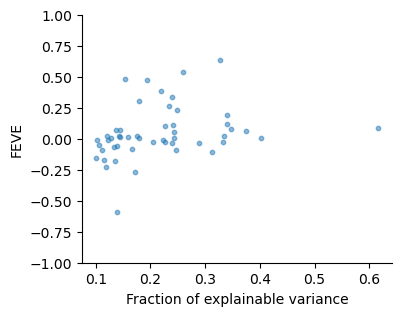

In [ ]:
idx = np.where(fev_all[ineur]>0.1)[0]
fig, ax = plt.subplots(figsize=(4,4))
plt.scatter(fev_all[ineur[idx]], varexp_ratio[idx], s=10, alpha=0.5)
plt.xlabel('Fraction of explainable variance')
plt.ylabel('FEVE')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim([-1, 1])
ax.set_aspect(0.8/ax.get_data_ratio(), adjustable='box')

In [ ]:
if not os.path.exists(model_path):
    torch.save(best_state_dict, model_path)
    print('saved model', model_path)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

saved model ../weights/sc_2layer_fev-1_16_320_clamp_sensorium_depthsep_pool.pt
loaded model ../weights/sc_2layer_fev-1_16_320_clamp_sensorium_depthsep_pool.pt


# visualize weights

In [ ]:
conv1_W = model.core.features.layer0.conv.weight.detach().cpu().numpy()
print(conv1_W.shape)
conv1_W = conv1_W.squeeze()
print(conv1_W.shape)

conv1_W_ratio = np.zeros(len(conv1_W))
for i in range(len(conv1_W)):
    iW = conv1_W[i]
    conv1_W_ratio[i] = iW[iW>0].sum() / iW[iW<0].sum()

(16, 1, 25, 25)
(16, 25, 25)


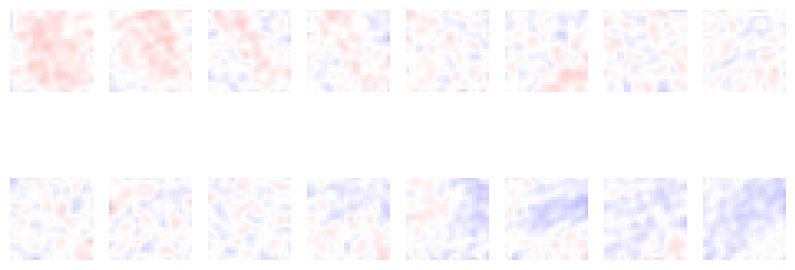

In [ ]:
isort = np.argsort(conv1_W_ratio)
# visualize conv1 kernels
plt.figure(figsize=(10, 4))
for i in range(16):
    plt.subplot(2, 8, i+1)
    im = conv1_W[isort[i]]
    #  gausian filter to visualize the kernel
    from scipy.ndimage import gaussian_filter
    im = gaussian_filter(im, 1)
    plt.imshow(im, cmap='bwr', vmin=-0.1, vmax=0.1)
    plt.axis('off')

In [ ]:
Wc = model.readout.Wc.detach().cpu().numpy().squeeze()
print(Wc.shape, Wc.min(), Wc.max())

(107, 192) -0.10619184 0.04666741


In [ ]:
np.random.seed(0)
isort_neurons = np.argsort(fev_all)[::-1]
ineurons = isort_neurons

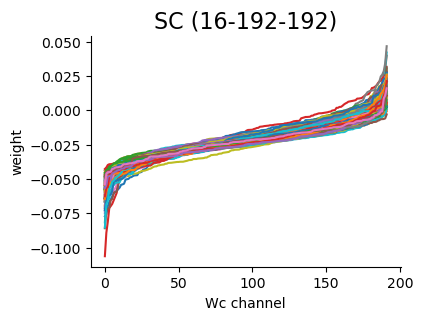

In [ ]:
plt.figure(figsize=(4,3))
Wc_tmp = Wc[ineurons]
for i in range(Wc_tmp.shape[0]):
    plt.plot(np.sort(Wc_tmp[i]))
plt.xlabel('Wc channel')
plt.ylabel('weight')
plt.title(f'SC (16-192-192)', fontsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [ ]:
# the spatial conv
conv2_W = model.core.features.layer1.ds_conv.spatial_conv.weight.detach().cpu().numpy()
print(conv2_W.shape)
conv2_W = conv2_W.squeeze()
print(conv2_W.shape)

(192, 1, 9, 9)
(192, 9, 9)


IndexError: index 192 is out of bounds for axis 0 with size 192

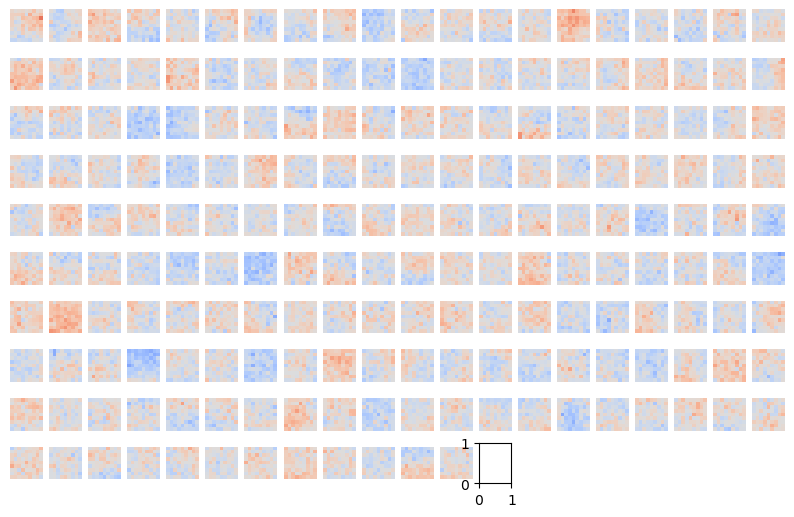

In [ ]:
# visualize conv2 kernels
plt.figure(figsize=(10, 10))
for i in range(320):
    plt.subplot(16, 20, i+1)
    plt.imshow(conv2_W[i], cmap='coolwarm', vmin=-0.1, vmax=0.1)
    plt.axis('off')

In [ ]:
# # change model Wx and Wy
Wx = model.readout.Wx.detach().cpu().numpy()
Wy = model.readout.Wy.detach().cpu().numpy()
Wc = model.readout.Wc.detach().cpu().numpy()
# outer product of Wx and Wy
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
print(Wxy.shape)

(107, 33, 38)


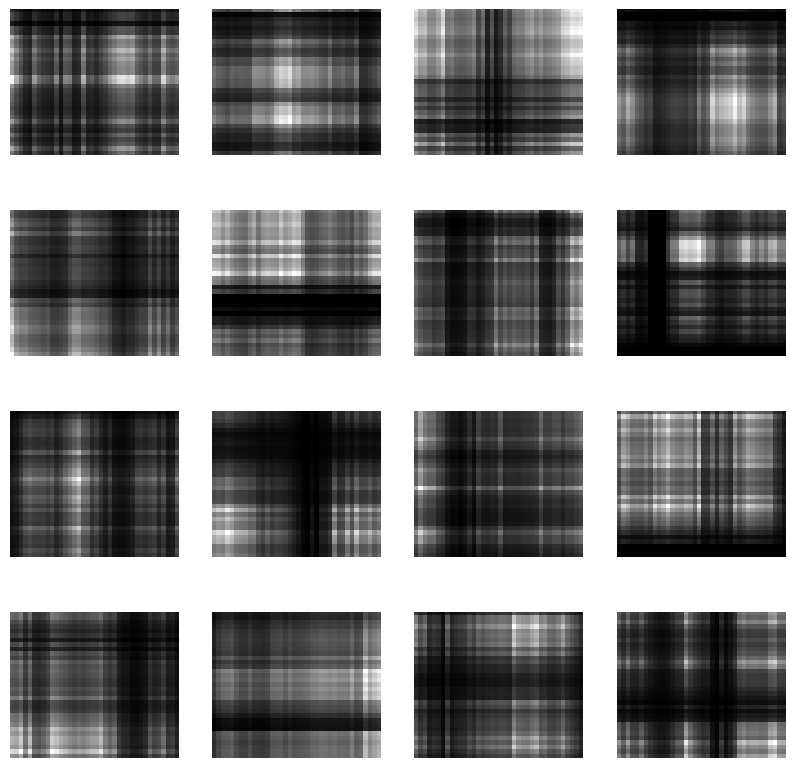

In [ ]:
np.random.seed(42)
ineurons = np.random.choice(len(Wxy), 16, replace=False)
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i, ineuron in enumerate(ineurons):
    ax[i//4, i%4].imshow(Wxy[ineuron], cmap='gray')
    ax[i//4, i%4].axis('off')
plt.show()

# power law

1.0543071165987108


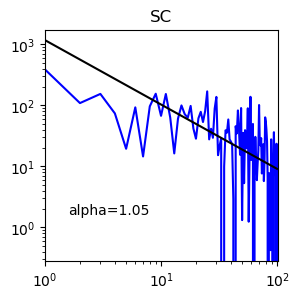

In [ ]:
from approxineuro.data_utils import get_powerlaw, cvPCA
ss = cvPCA(spks_test_rep.cpu().numpy())
xend = 100
plt.figure(figsize=(3,3))
alpha, ypred = get_powerlaw(ss, np.arange(10, xend))
print(alpha)
plt.loglog(np.arange(1,xend+1), ss[:xend], color='blue')
plt.loglog(np.arange(1,xend+1), ypred[:xend], label=f'alpha={alpha:.2f}', color='k')
plt.xlim([1, xend+1])
# put text on the plot
plt.text(0.1, 0.2, f'alpha={alpha:.2f}', transform=plt.gca().transAxes)
plt.title(f'SC')
ss_pred_test = ss.copy()
alpha_pred_test = alpha.copy()

# FEVE change with nlayers

In [ ]:
nlayers = 2
nconv1 = 192
nconv2 = 192

feve_all_layers = []
cc_all_layers = []
for nlayers in range(1, 5):
    model, in_channels = build_model(nlayers, nconv1, nconv2, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes, 
                        depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization)

    weight_path = '/home/carsen/dm11/Farah/EncodingModel'
    weight_path = '../weights'
    model_path = create_model_name(weight_path, in_channels, fev_threshold, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes,
                                    depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization, gabor=gabor,
                                    rank=1, orth_reg=orth_reg, highvar=highvar, use_30k=use_30k, l1_readout=0.0)
    print(model_path)

    model.load_state_dict(torch.load(model_path))

    varexp_all = np.zeros((2, len(ineur)))
    cc_all = np.zeros((2, len(ineur)))
    model.eval()
    for i in range(2):
        spks_test = spks_test_rep[i].T
        test_loss, varexp_full, cc_full, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test)
        varexp_all[i] = varexp_full
        cc_all[i] = cc_full
    varexp_ratio = varexp_all.mean(axis=0) / fev_all[ineur]
    # test_loss, varexp_full, cc_all, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test_rep.mean(0).T)
    idx = np.where(fev_all[ineur]>0.)[0]
    print('varexp ratio of neurons with fev>0:', varexp_ratio[idx].mean(), cc_all[:, ineur[idx]].mean())
    idx = np.where(fev_all[ineur]>0.1)[0]
    print('varexp ratio of neurons with fev>0.1:', varexp_ratio[idx].mean(), cc_all[:, ineur[idx]].mean())
    feve_all_layers.append(varexp_ratio[idx].mean())
    cc_all_layers.append(cc_all[:, idx].mean())

input shape of readout:  (192, 33, 38)
../weights/sc_1layer_fev-1_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: -0.12364985934697287 0.05719755283774784
varexp ratio of neurons with fev>0.1: -0.025454622815933726 0.06887994963966776
input shape of readout:  (192, 33, 38)
../weights/sc_2layer_fev-1_192_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: 0.055485489763387776 0.1121222730250268
varexp ratio of neurons with fev>0.1: 0.04224718780106123 0.12921726554661292
input shape of readout:  (192, 33, 38)
../weights/sc_3layer_fev-1_192_192_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: 0.0938626605477265 0.11760186154023335
varexp ratio of neurons with fev>0.1: 0.0584432551032916 0.13362553637474775
input shape of readout:  (192, 33, 38)
../weights/sc_4layer_fev-1_192_192_192_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: 0.08650004507831226 0.11802702480389808
varexp ratio of neurons w

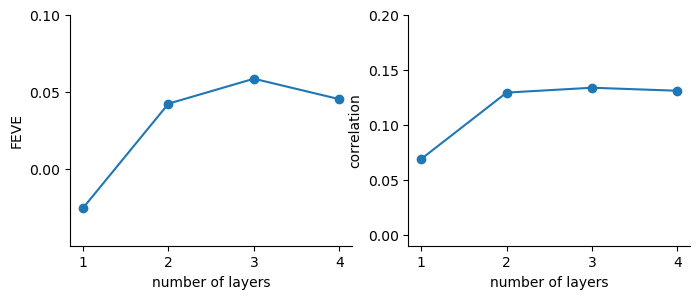

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(np.arange(1, 5), feve_all_layers, marker='o')
ax[0].set_xlabel('number of layers')
ax[0].set_ylabel('FEVE')
ax[0].set_ylim(-0.05, 0.1)
ax[0].set_yticks([0, 0.05, 0.1])
ax[1].plot(np.arange(1, 5), cc_all_layers, marker='o')
ax[1].set_xlabel('number of layers')
ax[1].set_ylabel('correlation')
ax[1].set_ylim(-0.01, 0.2)
ax[1].set_yticks([0, 0.05, 0.1, 0.15, 0.2])
# tight layout
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

In [ ]:
len(idx)

50

# LN model

In [12]:
img_downsample = 6
img_train, img_val, img_test, spks_train, spks_val, spks_test_rep, fev_all = load_sc_data(img_downsample = img_downsample,
                 use_sensorium_normalization = False,
                 use_zscore_normalization = True,
                 data_path = 'data/sc_processed_data.npz')

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test_rep.shape, spks_test_rep.min(), spks_test_rep.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

(1020, 66, 77) (254, 66, 77) (136, 66, 77)
(107, 1020) (107, 254) (2, 107, 136)
(107,)
downsample images:
train images: (1020, 11, 12)
val images: (254, 11, 12)
test images: (136, 11, 12)
spks_train:  (107, 1020) -0.6189248 19.500912
spks_val:  (107, 254) -0.6189248 22.76846
spks_test:  (2, 107, 136) -0.6189248 18.038963
img_train:  (1020, 11, 12) -2.1710794 2.1371822
img_val:  (254, 11, 12) -2.1710794 2.1371822
img_test:  (136, 11, 12) -2.1710794 2.1371822


In [13]:
def ridge_model(img_train, img_val, img_test, spks_train, spks_val, spks_test, alpha=1.0, return_model=False):
    from sklearn.linear_model import Ridge
    clf = Ridge(alpha=alpha, fit_intercept=True)
    clf.fit(img_train.squeeze().reshape(img_train.shape[0], -1), spks_train.T)
    spks_pred_train = clf.predict(img_train.squeeze().reshape(img_train.shape[0], -1)).T
    spks_pred_val = clf.predict(img_val.squeeze().reshape(img_val.shape[0], -1)).T
    spks_pred_test = clf.predict(img_test.squeeze().reshape(img_test.shape[0], -1)).T

    # varexp
    varexp_train = 1 - ((spks_train - spks_pred_train)**2).sum(axis=1) / ((spks_train - spks_train.mean(axis=1)[:, None])**2).sum(axis=1)
    varexp_val = 1 - ((spks_val - spks_pred_val)**2).sum(axis=1) / ((spks_val - spks_val.mean(axis=1)[:, None])**2).sum(axis=1)
    varexp_test = 1 - ((spks_test - spks_pred_test)**2).sum(axis=1) / ((spks_test - spks_test.mean(axis=1)[:, None])**2).sum(axis=1)
    # print(varexp_train.mean(), varexp_val.mean(), varexp_test.mean())

    # correlation
    NN = spks_train.shape[0]
    cc_test = np.zeros(NN)  
    cc_val = np.zeros(NN)
    cc_train = np.zeros(NN)
    for i in range(NN):
        cc_test[i] = np.corrcoef(spks_test[i], spks_pred_test[i])[0,1]
        cc_val[i] = np.corrcoef(spks_val[i], spks_pred_val[i])[0,1]
        cc_train[i] = np.corrcoef(spks_train[i], spks_pred_train[i])[0,1]
    # print(cc_train.mean(), cc_val.mean(), cc_test.mean())
    if return_model:
        return varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test, clf
    return varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test

fev_threshold = 0
ineur = np.where(fev_all > fev_threshold)[0]
print(f'selecting {len(ineur)} neurons with fev > {fev_threshold}') 
alpha_list = np.logspace(-3, 6, 20)
res = []
for alpha in alpha_list:
    varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test = ridge_model(img_train, img_val, img_test, spks_train, spks_val, spks_test_rep[0], alpha=alpha)
    # varexp_train = varexp_train / fev_all
    # varexp_val = varexp_val / fev_all
    # varexp_test = varexp_test / fev_all
    res.append([varexp_train[ineur].mean(), varexp_val[ineur].mean(), varexp_test[ineur].mean(), cc_train[ineur].mean(), cc_val[ineur].mean(), cc_test[ineur].mean()])

selecting 78 neurons with fev > 0


Text(0.5, 0.98, 'Ridge regression (zscore spks), downsample=6')

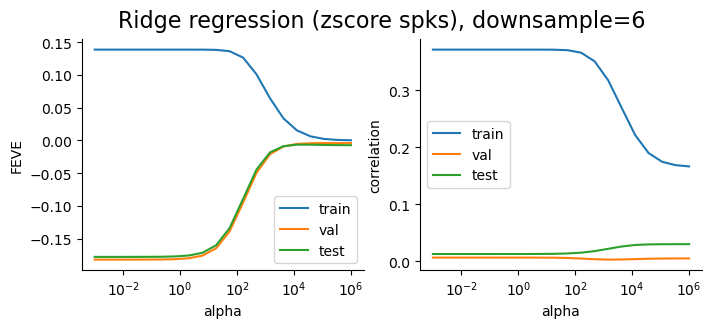

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
train_res = np.array(res)[:, 0]
val_res = np.array(res)[:, 1]
test_res = np.array(res)[:, 2]
train_cc = np.array(res)[:, 3]
val_cc = np.array(res)[:, 4]
test_cc = np.array(res)[:, 5]

ax[0].plot(alpha_list, train_res, label='train')
ax[0].plot(alpha_list, val_res, label='val')
ax[0].plot(alpha_list, test_res, label='test')
ax[0].set_xscale('log')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('FEVE')
ax[0].legend()

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].plot(alpha_list, train_cc, label='train')
ax[1].plot(alpha_list, val_cc, label='val')
ax[1].plot(alpha_list, test_cc, label='test')

ax[1].set_xscale('log')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('correlation')
ax[1].legend()

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# set title of the figure
fig.suptitle(f'Ridge regression (zscore spks), downsample={img_downsample}', fontsize=16)

In [15]:
varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test, model = ridge_model(img_train, img_val, img_test, spks_train, spks_val, spks_test_rep[0], alpha=1000, return_model=True)
# varexp_train = varexp_train / fev_all
# varexp_val = varexp_val / fev_all
# varexp_test = varexp_test / fev_all
print(varexp_train[ineur].mean(), varexp_val[ineur].mean(), varexp_test[ineur].mean())
print(cc_train[ineur].mean(), cc_val[ineur].mean(), cc_test[ineur].mean())

Ly, Lx = img_train.shape[-2:]
W = model.coef_
W = W.reshape(W.shape[0], Ly, Lx)
print(W.shape)

0.07674837 -0.028211266 -0.024539594
0.3308466278275655 0.0028153531864969807 0.020248767021893373
(107, 11, 12)


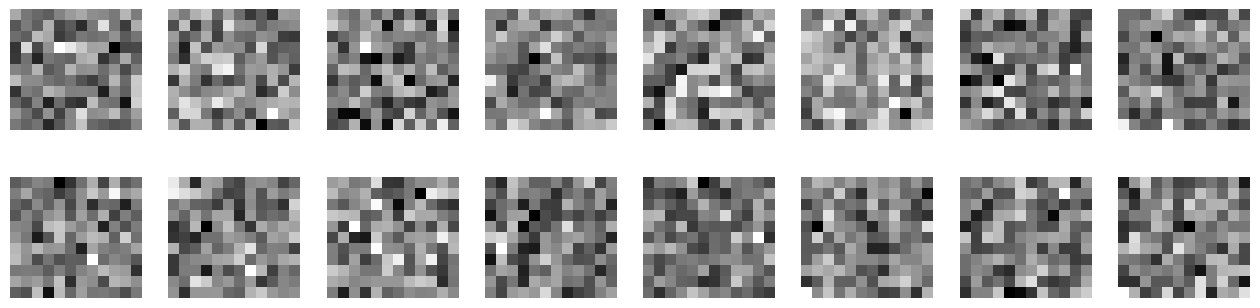

In [16]:
n_weight_show = 16
idx_show = np.argsort(cc_test)[::-1][:n_weight_show]
nrow = 2
ncol = n_weight_show // nrow
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*2, nrow*2))
for i in range(n_weight_show):
    # smooth the kernel
    from scipy.ndimage import gaussian_filter
    # wshow = gaussian_filter(W[idx_show[i]], 2)
    # ax[i//ncol, i%ncol].imshow(wshow, cmap='bwr', vmin=-0.01, vmax=0.01)
    wshow = W[idx_show[i]]
    ax[i//ncol, i%ncol].imshow(wshow, cmap='gray')
    ax[i//ncol, i%ncol].axis('off')

# LN model with poisson loss

In [18]:
img_downsample = 2
img_train, img_val, img_test, spks_train, spks_val, spks_test_rep, fev_all = load_sc_data(img_downsample = img_downsample,
                 use_sensorium_normalization = True,
                 use_zscore_normalization = False,
                 data_path = 'data/sc_processed_data.npz')

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test_rep.shape, spks_test_rep.min(), spks_test_rep.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

(1020, 66, 77) (254, 66, 77) (136, 66, 77)
(107, 1020) (107, 254) (2, 107, 136)
(107,)
downsample images:
train images: (1020, 33, 38)
val images: (254, 33, 38)
test images: (136, 33, 38)
spks_train:  (107, 1020) 0.0 19.869833
spks_val:  (107, 254) 0.0 23.20108
spks_test:  (2, 107, 136) 0.0 18.47648
img_train:  (1020, 33, 38) -2.170586 2.1355014
img_val:  (254, 33, 38) -2.170586 2.1355014
img_test:  (136, 33, 38) -2.170586 2.1355014


In [21]:
fev_threshold = -1
ineur = np.where(fev_all > fev_threshold)[0]
print(f'selecting {len(ineur)} neurons with fev > {fev_threshold}') 

spks_train = torch.from_numpy(spks_train[ineur].T)
spks_val = torch.from_numpy(spks_val[ineur].T)
spks_test_rep = torch.from_numpy(spks_test_rep[:, ineur])    
spks_test = spks_test_rep[0].T

print(spks_train.shape, spks_val.shape, spks_test.shape)

img_train = torch.from_numpy(img_train).to(device).unsqueeze(1)
img_val = torch.from_numpy(img_val).to(device).unsqueeze(1)
img_test = torch.from_numpy(img_test).to(device).unsqueeze(1)

print(img_train.shape, img_val.shape, img_test.shape)

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test.shape, spks_test.min(), spks_test.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

input_Ly, input_Lx = img_train.shape[-2:]

selecting 107 neurons with fev > -1
torch.Size([1020, 107]) torch.Size([254, 107]) torch.Size([136, 107])
torch.Size([1020, 1, 33, 38]) torch.Size([254, 1, 33, 38]) torch.Size([136, 1, 33, 38])
spks_train:  torch.Size([1020, 107]) tensor(0.) tensor(19.8698)
spks_val:  torch.Size([254, 107]) tensor(0.) tensor(23.2011)
spks_test:  torch.Size([136, 107]) tensor(0.) tensor(18.4765)
img_train:  torch.Size([1020, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
img_val:  torch.Size([254, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
img_test:  torch.Size([136, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)


In [24]:
from torch import nn
NN = spks_train.shape[1]
Ly, Lx = img_test.shape[-2:]

# train a linear-nonlinear model use torch
# Y = elu(W * X + b)
# W: NN x Ly*Lx 
# X: Ly*Lx 
# Y: NN 
# b: NN

# device = torch.device('cpu')
W = 0.01 * torch.randn(NN, Ly*Lx, device=device, requires_grad=True)
b = 0.01 * torch.randn(NN, device=device, requires_grad=True)
W = nn.Parameter(W)
b = nn.Parameter(b)
optimizer = torch.optim.Adam([W, b], lr=1e-3)


n_epochs = 100
for epoch in range(n_epochs):
    optimizer.zero_grad()
    Y = torch.nn.functional.elu((W @ img_train.view(-1, Ly*Lx).T).T + b) 
    # poisson loss
    loss = (Y - spks_train * torch.log(Y)).sum(axis=0).mean()
    # mse loss
    # loss = ((Y - spks_train)**2).mean(axis=0).mean()
    # l2 loss
    l2_loss = (W**2).sum() + (b**2).sum()
    loss += 0.1*l2_loss
    loss.backward()
    optimizer.step()
    if epoch%10==0:
        print(f'epoch {epoch}, loss = {loss.item(), l2_loss.item()}')
        # calculate variance explained
        Y_val = torch.nn.functional.elu((W @ img_val.view(-1, Ly*Lx).T).T + b) + 1
        varexp = 1 - (Y_val - spks_val).var(axis=0) / spks_val.var(axis=0)
        print(f'varexp = {varexp.mean()}')

epoch 0, loss = (nan, 13.407368659973145)
varexp = -0.1596498042345047
epoch 10, loss = (nan, 15.848854064941406)
varexp = -0.7585952877998352
epoch 20, loss = (nan, 17.805707931518555)
varexp = -1.0227099657058716
epoch 30, loss = (nan, 18.97649383544922)
varexp = -1.0769425630569458
epoch 40, loss = (nan, 19.679637908935547)
varexp = -1.0523521900177002
epoch 50, loss = (nan, 20.204566955566406)
varexp = -1.018996000289917
epoch 60, loss = (nan, 20.68100357055664)
varexp = -0.9900180697441101
epoch 70, loss = (nan, 21.12504005432129)
varexp = -0.9583154320716858
epoch 80, loss = (nan, 21.57845115661621)
varexp = -0.9375667572021484
epoch 90, loss = (nan, 22.063480377197266)
varexp = -0.9163715839385986


# gabor model